This notebook illustrates how to measure importance ranking by different bias-selection approaches for BERT<sub>BASE</sub> on low-data SST-2 dataset.

In [ ]:
!pip install -r requirements.txt

Run the initialization and evalutor below

In [2]:
import argparse
import os
import logging
import sys
import re
from functools import reduce
import pickle
import numpy as np
import matplotlib.pyplot as plt
from seaborn import heatmap
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import f1_score, matthews_corrcoef, accuracy_score
import torch
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from datasets import load_dataset
from transformers.optimization import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from datasets.arrow_dataset import Dataset
import warnings
#warnings.filterwarnings('ignore')
warnings.showwarning = lambda *args, **kwargs: None

def setup_logging():
    logging.basicConfig(stream=sys.stdout, format='%(asctime)s - %(module)s - %(levelname)s - %(message)s',
                        level=logging.INFO)
    
setup_logging()
LOGGER = logging.getLogger(__name__)

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

TASK_TO_KEYS = {
    "cola": ("sentence", None),
    "mnli": ("premise", "hypothesis"),
    "mrpc": ("sentence1", "sentence2"),
    "qnli": ("question", "sentence"),
    "qqp": ("question1", "question2"),
    "rte": ("sentence1", "sentence2"),
    "sst2": ("sentence", None),
    "stsb": ("sentence1", "sentence2"),
    "wnli": ("sentence1", "sentence2"),
    "cb": ("premise", "hypothesis"),
    "wic": ("sentence1", "sentence2"),
}

TASK_TO_METRICS = {
    "cola": ["MCC"],
    "mnli": ["Accuracy"],
    "mrpc": ["Accuracy", "F1"],
    "qnli": ["Accuracy"],
    "qqp": ["Accuracy", "F1"],
    "rte": ["Accuracy"],
    "sst2": ["Accuracy"],
    "stsb": ["Spearman", "Pearson"],
    "wnli": ["Accuracy"],
    "cb": ["F1"],
    "wic": ["Accuracy"],
}

METRIC_NAME_TO_FUNCTION = {
    "MCC": matthews_corrcoef,
    "Accuracy": accuracy_score,
    "F1": f1_score,
    "Spearman": spearmanr,
    "Pearson": pearsonr,
}

BIAS_TERMS_DICT = {
    'intermediate': 'intermediate.dense.bias',
    'key': 'attention.self.key.bias',
    'query': 'attention.self.query.bias',
    'value': 'attention.self.value.bias',
    'm1': 'attention.output.dense.bias',
    'm3': 'output.dense.bias',
    'LN2': 'output.LayerNorm.bias',
    'LN1': 'attention.output.LayerNorm.bias',
    'all': 'bias',
}

TASK_NAME_TO_SUBMISSION_FILE_NAME = {
    "cola": "CoLA.tsv",
    "mnli": ("MNLI-m.tsv", "MNLI-mm.tsv"),
    "mrpc": "MRPC.tsv",
    "qnli": "QNLI.tsv",
    "qqp": "QQP.tsv",
    "rte": "RTE.tsv",
    "sst2": "SST-2.tsv",
    "stsb": "STS-B.tsv",
    "wnli": "WNLI.tsv",
    "cb": "CB.tsv",
    "wic": "WiC.tsv",
}

TASK_IS_BINARY = {
    "cola": True,
    "mnli": False,
    "mrpc": True,
    "qnli": False,
    "qqp": True,
    "rte": False,
    "sst2": True,
    "stsb": True,
    "wnli": True,
    "cb": False,
    "wic": True,
}

BIAS_LAYER_NAME_TO_LATEX = {
    'attention.self.query.bias': '$\mathbf{b}_{q}^{\ell}$',
    'attention.self.key.bias': '$\mathbf{b}_{k}^{\ell}$',
    'attention.self.value.bias': '$\mathbf{b}_{v}^{\ell}$',
    'attention.output.dense.bias': '$\mathbf{b}_{m_1}^{\ell}$',
    'attention.output.LayerNorm.bias': '$\mathbf{b}_{LN_1}^{\ell}$',
    'intermediate.dense.bias': '$\mathbf{b}_{m_2}^{\ell}$',
    'output.dense.bias': '$\mathbf{b}_{m_3}^{\ell}$',
    'output.LayerNorm.bias': '$\mathbf{b}_{LN_2}^{\ell}$',

    'attention.output.LayerNorm.weight': '$\mathbf{g}_{LN_1}^{\ell}$',
    'output.LayerNorm.weight': '$\mathbf{g}_{LN_2}^{\ell}$',
    'attention.self.query.weight': '$\mathbf{w}_{q}^{\ell}$',
    'attention.self.key.weight': '$\mathbf{w}_{k}^{\ell}$',
    'attention.self.value.weight': '$\mathbf{w}_{v}^{\ell}$',
    'attention.output.dense.weight': '$\mathbf{w}_{m_1}^{\ell}$',
    'intermediate.dense.weight': '$\mathbf{w}_{m_2}^{\ell}$',
    'output.dense.weight': '$\mathbf{w}_{m_3}^{\ell}$',
}


class GLUEvaluator:


    def __init__(self, task_name, model_name, device,training_data_number,fine_tune_type,bias_terms):

        self.task_name = task_name
        self.model_name = model_name
        self.device = device

        self.training_data_number = training_data_number
        self.fine_tune_type = fine_tune_type
        self.bias_terms = bias_terms

        # initialization
        self.is_regression = task_name == 'stsb'
        self.num_labels = None
        self.data_loaders = None
        self.batch_size = None
        self.model = None
        self.optimizer = None
        self.learning_rate = None
        self.evaluations = None
        self.encoder_trainable = None
        self.masks = None
        self.idx_to_label = None

    def preprocess_dataset(self, padding, max_sequence_len, batch_size, train_size=None):

        LOGGER.info(f'Downloading dataset: {self.task_name}')
        if self.task_name in {'cb', 'wic'}:
            datasets = load_dataset('super_glue', self.task_name)
        else:
            datasets = load_dataset('glue', self.task_name)

        self.batch_size = batch_size
        tokenizer = AutoTokenizer.from_pretrained(self.model_name)

        is_regression = self.task_name == "stsb"
        if not is_regression:
            if "label" in datasets["train"].features and hasattr(datasets["train"].features["label"], "names"):
                label_list = datasets["train"].features["label"].names
                self.idx_to_label = {k: v for k, v in enumerate(datasets['train'].features['label'].__dict__['_int2str'])}
                self.num_labels = len(label_list)
            else:
                label_feature = datasets["train"].features["label"]
                self.idx_to_label = {k: v for k, v in enumerate(label_feature._int2str)}
                self.num_labels = len(self.idx_to_label)
        else:
            self.num_labels = 1

        sentence1_key, sentence2_key = TASK_TO_KEYS[self.task_name]

        def _preprocess_function(examples):
            # Tokenize the texts
            args = (
                (examples[sentence1_key],) if sentence2_key is None else (
                    examples[sentence1_key], examples[sentence2_key])
            )
            result = tokenizer(*args, padding=padding, max_length=max_sequence_len, truncation=True)
            return result

        datasets = datasets.map(_preprocess_function, batched=True, load_from_cache_file=False)

        self.data_loaders = dict()

        if train_size:
            perm = np.random.permutation(len(datasets['train']))[:train_size]
            self.data_loaders['train'] = Dataset.from_dict(datasets['train'][perm])
        else:
            self.data_loaders['train'] = datasets['train']

        if self.task_name == 'mnli':
            self.data_loaders['validation_matched'] = datasets['validation_matched']
            self.data_loaders['validation_mismatched'] = datasets['validation_mismatched']
            self.data_loaders['test_matched'] = datasets['test_matched']
            self.data_loaders['test_mismatched'] = datasets['test_mismatched']
        elif self.task_name in {'cb','wic'}:
            self.data_loaders['validation'] = datasets['validation']
            if 'test' in datasets:
                self.data_loaders['test'] = datasets['test']
        else:
            self.data_loaders['validation'] = datasets['validation']
            self.data_loaders['test'] = datasets['test']

        for dataset_name, dataset in self.data_loaders.items():
            self.data_loaders[dataset_name] = self._convert_dataset_to_data_loader(dataset=dataset,
                                                                                   model_name=self.model_name,
                                                                                   batch_size=self.batch_size,
                                                                                   random_sampler=dataset_name == 'train',
                                                                                   test='test' in dataset_name)

    def training_preparation(self, learning_rate, optimizer, encoder_trainable, trainable_components=None,
                             verbose=True):

        if self.model:
            raise Exception('Training preparation was already completed.')

        if encoder_trainable and trainable_components:
            raise Exception(
                f"If encoder_trainable is True, you shouldn't supply trainable_components. "
                f"Got trainable_components: {trainable_components}")

        self.encoder_trainable = encoder_trainable
        # model declaration
        config = AutoConfig.from_pretrained(self.model_name, num_labels=self.num_labels, return_dict=True)
        self.model = AutoModelForSequenceClassification.from_pretrained(self.model_name, config=config)
        if not encoder_trainable:
            self._deactivate_relevant_gradients(trainable_components)

        # optimizer declaration
        if optimizer == 'adam':
            self.optimizer = Adam(self.model.parameters(), lr=learning_rate)
        elif optimizer == 'adamw':
            self.optimizer = AdamW(self.model.parameters(), lr=learning_rate, correct_bias=True)
        else:
            raise Exception(f"optimizer arg must be in ['adam', 'adamw'], got: {optimizer}")

        self.learning_rate = learning_rate

        if verbose:
            print('\n\nTrainable Components:\n----------------------------------------\n')
            total_trainable_params = 0
            for name, param in self.model.named_parameters():
                if param.requires_grad:
                    print(name, '  --->  ', param.shape)
                    total_trainable_params += param.shape[0] if len(param.shape) == 1 else param.shape[0] * param.shape[
                        1]
            print(
                f'\n----------------------------------------\nNumber of Trainable Parameters: {total_trainable_params}\n')

        self.evaluations = {k: {metric_name: [] for metric_name in TASK_TO_METRICS[self.task_name]} for k in
                            self.data_loaders.keys()}


    def fisher_information(self,args,trainable_components,output_path=None):
                
        # fisher information
        self.model.eval()

        criteria = torch.nn.MSELoss() if self.is_regression else torch.nn.CrossEntropyLoss()
            
        num_layers = self.model.config.num_hidden_layers 
        grad = []

        def _calc_mean_grad(grad_data):
            return np.mean(np.array(grad_data.data)**2)
            #return np.sum(np.array(grad_data.data)**2) 
        
        for step, batch in enumerate(self.data_loaders['train']):

            self.model.zero_grad()

            # move batch data to gpu
            if self.device is not None:
                batch = tuple(obj.cuda(self.device) for obj in batch)

            if 'roberta' in self.model_name:
                input_ids, attention_mask, labels = batch
                token_type_ids = None
            else:
                input_ids, attention_mask, token_type_ids, labels = batch

            # forward pass
            outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            outputs = outputs.logits

            # loss calculation
            labels = labels.view(-1)
            outputs = outputs.view(-1) if self.is_regression else outputs.view(-1, self.num_labels)

            loss = criteria(outputs, labels)

            # backward pass (gradients calculation)
            loss.backward()

            # masking the relevant gradients (if needed)
            if self.masks:
                if 'roberta' in self.model_name:
                    for name, param in self.model.roberta.named_parameters():
                        param.grad[~self.masks[name]] = 0
                else:
                    for name, param in self.model.bert.named_parameters():
                        param.grad[~self.masks[name]] = 0

            # gradient clipping
            torch.nn.utils.clip_grad_norm_(parameters=self.model.parameters(), max_norm=1.0)

            # add fisher
            for base_name, base_param in self.model.named_parameters():
                if base_param.requires_grad and 'layer' in base_name:
                    for item in grad:
                        if item['name'] == base_name:
                            item['value'] += _calc_mean_grad(base_param.grad)
                            break
                    else:
                        grad.append({'name': base_name, 'value': _calc_mean_grad(base_param.grad)})

        for item in grad: 
            item['value']/=step+1#len(self.data_loaders['train'])

        def _get_component_name(name):
            return re.split(r'.[0-9]+.', name)[1]

        def _get_component_layer(name):
            return int(name.split('.')[3])

        keys = list(set(_get_component_name(c['name']) for c in grad))
        keys_mapper = {k: i for i, k in enumerate(keys)}

        total_weights = np.zeros(len(keys))
        for change in grad:
            total_weights[keys_mapper[_get_component_name(change['name'])]] += change['value']

        keys = [keys[i] for i in np.argsort(-total_weights)]
        keys_mapper = {k: i for i, k in enumerate(keys)}

        avg_column = np.zeros(len(keys))
        values_map = np.zeros((len(keys), num_layers + 1))
        for change in grad:
            avg_column[keys_mapper[_get_component_name(change['name'])]] += change['value']
            values_map[keys_mapper[_get_component_name(change['name'])], _get_component_layer(change['name'])] = change[
                'value']
        avg_column /= num_layers
        values_map[:, -1] = avg_column

        fig, ax = plt.subplots(figsize=(num_layers, len(keys)))
        xticklabels = [f'layer {i + 1}' for i in range(num_layers)]
        xticklabels.append('Avg.')

        keys = [BIAS_LAYER_NAME_TO_LATEX[key] for key in keys]
        heatmap(values_map, cmap="Blues", ax=ax, yticklabels=keys, xticklabels=xticklabels)

        plt.xticks(rotation=45)
        plt.yticks(rotation=0, ha='left')

        if output_path:
            plt.savefig(output_path)
            plt.clf()
        else:
            plt.show()

        if self.device is not None:
            self.model.cuda(self.device)

    def train_and_evaluate(self, num_epochs, output_path=None, evaluation_frequency=1):


        # validations
        if not self.data_loaders:
            raise Exception('data loaders were not initialized, please run "preprocess_dataset" before training.')

        if not self.model:
            raise Exception('model was not initialized, please run "training_preparation" before training.')

        # moving model to the required device
        if self.device is not None:
            self.model.cuda(self.device)

        # train and evaluate
        for epoch in range(num_epochs):
            # training for a single epoch
            self._train(self.data_loaders['train'], epoch)

            # evaluation
            if not epoch % evaluation_frequency:
                for dataloader_type, dataloader in self.data_loaders.items():
                    if not ('test' in dataloader_type):
                        results = self._evaluate(dataloader, dataloader_type.upper())
                        for metric_name, result in results.items():
                            self.evaluations[dataloader_type][metric_name].append(result)
            print('')

            # plot learning curves
            #self.plot_learning_curves(output_path)

    def save(self, output_path):

        LOGGER.info(f'Saving the model to: {output_path}')

        self.model.cpu()
        data = {'model': self.model, 'model_name': self.model_name, 'task_name': self.task_name,
                'learning_rate': self.learning_rate, 'evaluations': self.evaluations,
                'batch_size': self.batch_size, 'num_labels': self.num_labels,
                'encoder_trainable': self.encoder_trainable}
        with open(output_path, 'wb') as file:
            pickle.dump(data, file)

    @staticmethod
    def load(path, gpu_device):

        with open(path, 'rb') as file:
            data = pickle.load(file)
        evaluator = GLUEvaluator(data['task_name'], data['model_name'], gpu_device)
        evaluator.num_labels = data['num_labels']
        evaluator.batch_size = data['batch_size']
        evaluator.model = data['model']
        evaluator.learning_rate = data['learning_rate']
        evaluator.evaluations = data['evaluations']
        evaluator.encoder_trainable = data.get('encoder_trainable', None)

        return evaluator

    def export_model_test_set_predictions(self, output_path):

        # validations
        if not self.data_loaders:
            raise Exception(
                'data loaders were not initialized, please run "preprocess_dataset" before test evaluation.')

        if not self.model:
            raise Exception('model was not initialized, please run "training_preparation" before test evaluation.')

        # move the model the required device
        if self.device is not None:
            self.model.cuda(self.device)

        LOGGER.info(f'Exporting model test set predictions to: {output_path}.')

        test_data_loaders = dict()
        if self.task_name == 'mnli':
            test_data_loaders["MNLI-m.tsv"] = self.data_loaders["test_matched"]
            test_data_loaders["MNLI-mm.tsv"] = self.data_loaders["test_mismatched"]
        else:
            test_data_loaders[TASK_NAME_TO_SUBMISSION_FILE_NAME[self.task_name]] = self.data_loaders["test"]

        # change to eval mode
        self.model.eval()

        for prediction_file_name, dataloader in test_data_loaders.items():
            results = list()
            counter = 0
            num_samples = len(dataloader.dataset)
            for batch in dataloader:
                # move batch data to gpu
                if self.device is not None:
                    batch = tuple(obj.cuda(self.device) for obj in batch)

                input_ids, attention_mask, token_type_ids = batch

                # forward pass
                with torch.no_grad():
                    outputs = self.model(input_ids=input_ids, attention_mask=attention_mask,
                                         token_type_ids=token_type_ids)
                    outputs = outputs.logits

                # aggregate results
                if self.is_regression:
                    outputs = outputs.view(-1)
                    outputs = outputs.detach().cpu().numpy()
                    results.extend(list(outputs))
                else:
                    outputs = outputs.view(-1, self.num_labels)
                    outputs = outputs.detach().cpu().numpy()
                    outputs = np.argmax(outputs, axis=-1)
                    if TASK_IS_BINARY[self.task_name]:
                        results.extend([int(pred) for pred in outputs])
                    else:
                        results.extend([self.idx_to_label[pred] for pred in outputs])

                counter += len(outputs)
                print(f'Test inference progress: {counter}/{num_samples}\r', end='')
            print('')

            # save the test set results (in "GLUE/SuperGLUE test server" format)
            with open(os.path.join(output_path, prediction_file_name), 'w') as file:
                file.write('index\tprediction\n')
                for idx, result in enumerate(results):
                    file.write(f'{idx}\t{result}\n')

        LOGGER.info(f'Test set inference is done, inference artifacts are: {list(test_data_loaders.keys())}')

    def plot_learning_curves(self, output_path=None):

        for metric_name in TASK_TO_METRICS[self.task_name]:
            for dataloader_type, results_mapper in self.evaluations.items():
                if not ('test' in dataloader_type):
                    label = f'{dataloader_type} (max is {round(max(results_mapper[metric_name]) * 100, 2)})'
                    plt.plot(results_mapper[metric_name], label=label)
            plt.title(f'Learning Curves - {self.task_name}')
            plt.xlabel('Epoch')
            plt.ylabel(metric_name)
            plt.legend()
            if output_path:
                if self.fine_tune_type == 'bitfit':
                    plt.savefig(os.path.join(output_path, f'learning_curves_{metric_name.lower()}_{self.task_name}_{self.training_data_number}_{self.fine_tune_type}_{self.bias_terms}'))
                    plt.clf()
                else:
                    plt.savefig(os.path.join(output_path, f'learning_curves_{metric_name.lower()}_{self.task_name}_{self.training_data_number}_{self.fine_tune_type}'))
                    plt.clf() 
            else:
                plt.show()

    def plot_terms_changes(self, output_path=None):

        if output_path:
            LOGGER.info(f'Saving the bias terms changes to: {output_path}')

        if 'roberta' in self.model_name:
            base_model = AutoModelForSequenceClassification.from_pretrained(self.model_name, return_dict=True).roberta
            fine_tuned_model = self.model.cpu().roberta
        else:
            base_model = AutoModelForSequenceClassification.from_pretrained(self.model_name, return_dict=True).bert
            fine_tuned_model = self.model.cpu().bert

        num_layers = self.model.config.num_hidden_layers

        def _calc_mean_diff(ft_p, base_p):
            return np.mean(np.abs(np.array(ft_p.data - base_p.data)))

        changes = []
        for ft_name, ft_param in fine_tuned_model.named_parameters():
            if ft_param.requires_grad and 'layer' in ft_name:
                for base_name, base_param in base_model.named_parameters():
                    if ft_name == base_name:
                        changes.append({'name': ft_name, 'value': _calc_mean_diff(ft_param, base_param)})

        def _get_component_name(name):
            return re.split(r'.[0-9]+.', name)[1]

        def _get_component_layer(name):
            return int(name.split('.')[2])

        keys = list(set(_get_component_name(c['name']) for c in changes))
        keys_mapper = {k: i for i, k in enumerate(keys)}

        total_weights = np.zeros(len(keys))
        for change in changes:
            total_weights[keys_mapper[_get_component_name(change['name'])]] += change['value']

        keys = [keys[i] for i in np.argsort(-total_weights)]
        keys_mapper = {k: i for i, k in enumerate(keys)}

        avg_column = np.zeros(len(keys))
        values_map = np.zeros((len(keys), num_layers + 1))
        for change in changes:
            avg_column[keys_mapper[_get_component_name(change['name'])]] += change['value']
            values_map[keys_mapper[_get_component_name(change['name'])], _get_component_layer(change['name'])] = change[
                'value']
        avg_column /= num_layers
        values_map[:, -1] = avg_column

        fig, ax = plt.subplots(figsize=(num_layers, len(keys)))
        xticklabels = [f'layer {i + 1}' for i in range(num_layers)]
        xticklabels.append('Avg.')

        keys = [BIAS_LAYER_NAME_TO_LATEX[key] for key in keys]
        heatmap(values_map, cmap="Blues", ax=ax, yticklabels=keys, xticklabels=xticklabels)

        for i in range(values_map.shape[0]):
            value = values_map[i, -1]
            ax.text(num_layers + 1.3, i + 0.5, f"{value:.3f}", 
                    ha='center', va='center', color='black', fontsize=10)

        plt.xticks(rotation=45)
        plt.yticks(rotation=0, ha='left')

        if output_path:
            plt.savefig(output_path)
            plt.clf()
        else:
            plt.show()

        if self.device is not None:
            self.model.cuda(self.device)

    def plot_terms_angles(self, output_path=None):

        if output_path:
            LOGGER.info(f'Saving the bias terms changes to: {output_path}')

        if 'roberta' in self.model_name:
            base_model = AutoModelForSequenceClassification.from_pretrained(self.model_name, return_dict=True).roberta
            fine_tuned_model = self.model.cpu().roberta
        else:
            base_model = AutoModelForSequenceClassification.from_pretrained(self.model_name, return_dict=True).bert
            fine_tuned_model = self.model.cpu().bert

        num_layers = self.model.config.num_hidden_layers

        #our bias-efficient metric
        def _calc_projection_diff(ft_p, base_p):
            if np.arccos(np.clip(np.dot(ft_p.data.flatten(), base_p.data.flatten()) / (np.linalg.norm(ft_p.data.flatten()) * np.linalg.norm(base_p.data.flatten())), -1.0, 1.0)) * 180 / np.pi > 90:
                print('angle larger than 90')
                raise ValueError("angle larger than 90") # test

            if np.linalg.norm(ft_p.data.flatten()) == 0 or np.linalg.norm(base_p.data.flatten())==0:
                print('base p or ft_p is zero')
                raise ValueError("base p or ft_p is zero") # test

            if np.linalg.norm(ft_p.data.flatten())<np.linalg.norm(base_p.data.flatten()) or np.linalg.norm(ft_p.data.flatten()) == np.linalg.norm(base_p.data.flatten()):
                return np.dot(ft_p.data.flatten(), base_p.data.flatten())/np.linalg.norm(base_p.data.flatten())/np.linalg.norm(base_p.data.flatten())
            else:
                return np.dot(ft_p.data.flatten(), base_p.data.flatten())/np.linalg.norm(ft_p.data.flatten())/np.linalg.norm(ft_p.data.flatten())
        

        angle_changes =[]
        for ft_name, ft_param in fine_tuned_model.named_parameters():
            if ft_param.requires_grad and 'layer' in ft_name:
                for base_name, base_param in base_model.named_parameters():
                    if ft_name == base_name:
                        angle_changes.append({'name': ft_name, 'value': 1-_calc_projection_diff(ft_param.data, base_param.data)})

        def _get_component_name(name):
            return re.split(r'.[0-9]+.', name)[1]

        def _get_component_layer(name):
            return int(name.split('.')[2])

        keys = list(set(_get_component_name(c['name']) for c in angle_changes))
        keys_mapper = {k: i for i, k in enumerate(keys)}

        total_weights = np.zeros(len(keys))
        for change in angle_changes:
            total_weights[keys_mapper[_get_component_name(change['name'])]] += change['value']

        keys = [keys[i] for i in np.argsort(-total_weights)]
        keys_mapper = {k: i for i, k in enumerate(keys)}

        avg_column = np.zeros(len(keys))
        values_map = np.zeros((len(keys), num_layers + 1))
        for change in angle_changes:
            avg_column[keys_mapper[_get_component_name(change['name'])]] += change['value']
            values_map[keys_mapper[_get_component_name(change['name'])], _get_component_layer(change['name'])] = change[
                'value']
        avg_column /= num_layers
        values_map[:, -1] = avg_column

        fig, ax = plt.subplots(figsize=(num_layers, len(keys)))
        xticklabels = [f'layer {i + 1}' for i in range(num_layers)]
        xticklabels.append('Avg.')

        keys = [BIAS_LAYER_NAME_TO_LATEX[key] for key in keys]
        heatmap(values_map, cmap="Blues", ax=ax, yticklabels=keys, xticklabels=xticklabels)

        for i in range(values_map.shape[0]):
            value = values_map[i, -1]
            ax.text(num_layers + 1.3, i + 0.5, f"{value:.3f}", 
                    ha='center', va='center', color='black', fontsize=10)

        plt.xticks(rotation=45)
        plt.yticks(rotation=0, ha='left')

        if output_path:
            plt.savefig(output_path)
            plt.clf()
        else:
            plt.show()

        if self.device is not None:
            self.model.cuda(self.device)

            
    def set_uniform_mask(self, mask_size):

        if not self.encoder_trainable:
            raise Exception('In order to train with a random mask the encoder must be trainable.')

        if 'roberta' in self.model_name:
            model = self.model.roberta
        else:
            model = self.model.bert

        total_params = 0
        self.masks, params_per_component = dict(), dict()
        for name, param in model.named_parameters():
            self.masks[name] = torch.zeros(param.size(), dtype=torch.bool)
            component_params = reduce(lambda x, y: x * y, param.shape)
            params_per_component[name] = component_params
            total_params += component_params

        tunable_params_per_component = {k: int((v * mask_size) / total_params) for k, v in
                                        params_per_component.items()}

        LOGGER.info(f'Non-Masked params amount: {reduce(lambda x, y: x + y, tunable_params_per_component.values())}. '
                    f'Total params: {total_params}')

        for name, param in model.named_parameters():
            component_mask_size = tunable_params_per_component[name]
            component_params = params_per_component[name]
            indices = np.random.randint(0, component_params, component_mask_size)
            mask = self.masks[name]
            for index in indices:
                if len(param.shape) == 1:
                    mask[index] = True
                else:
                    mask[int(index / param.shape[1]), index % param.shape[1]] = True

    def set_row_and_column_random_mask(self):

        if not self.encoder_trainable:
            raise Exception('In order to train with a random mask the encoder must be trainable.')

        if 'roberta' in self.model_name:
            model = self.model.roberta
        else:
            model = self.model.bert

        self.masks = dict()
        total_params = 0
        for name, param in model.named_parameters():
            self.masks[name] = torch.zeros(param.size(), dtype=torch.bool)
            total_params += reduce(lambda x, y: x * y, param.shape)

            if ('encoder' not in name and 'pooler' not in name) or 'weight' not in name:
                continue

            if len(param.shape) == 1 and 'LayerNorm' in name:  # in case it's a LayerNorm
                self.masks[name][:] = True
                continue

            if np.random.randint(0, 2) or param.shape[0] < param.shape[1]:  # we randomly choose a column
                n_columns = int(param.shape[1])
                column_index = np.random.randint(0, n_columns)
                self.masks[name][:, column_index] = True
            else:  # we randomly choose rows
                bias_shape = int(param.shape[0])
                row_size = int(param.shape[1])
                n_rows_to_activate = int(bias_shape / row_size)
                row_indices = np.random.randint(0, bias_shape, n_rows_to_activate)
                self.masks[name][row_indices] = True

        LOGGER.info(f'Non-Masked params amount: {int(np.sum([np.sum(mask.numpy()) for mask in self.masks.values()]))}. '
                    f'Total params: {total_params}')

    def _deactivate_relevant_gradients(self, trainable_components):

        for param in self.model.parameters():
            param.requires_grad = False
        if trainable_components:
            trainable_components = trainable_components + ['pooler.dense.bias']
        trainable_components = trainable_components + ['classifier']
        for name, param in self.model.named_parameters():
            for component in trainable_components:

                if component == 'output.LayerNorm.bias':
                    if component in name and 'attention.output.LayerNorm.bias' not in name:
                        param.requires_grad = True
                        break
                elif component == 'output.dense.bias':
                    if component in name and 'attention.output.dense.bias' not in name:
                        param.requires_grad = True
                        break   
                else:     
                    if component in name:
                        param.requires_grad = True
                        break

    @staticmethod
    def convert_to_actual_components(components):
        return [BIAS_TERMS_DICT[component] for component in components]

    def _train(self, train_dataloader, epoch, max_grad_norm=1.0):

        # move to train mode
        self.model.train()

        # loss initialization
        criteria = torch.nn.MSELoss() if self.is_regression else torch.nn.CrossEntropyLoss()

        n = len(train_dataloader.dataset)
        trained_samples = loss_sum = 0
        for step, batch in enumerate(train_dataloader):
            # move batch data to gpu
            if self.device is not None:
                batch = tuple(obj.cuda(self.device) for obj in batch)

            if 'roberta' in self.model_name:
                input_ids, attention_mask, labels = batch
                token_type_ids = None
            else:
                input_ids, attention_mask, token_type_ids, labels = batch

            # forward pass
            outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            outputs = outputs.logits

            # loss calculation
            labels = labels.view(-1)
            outputs = outputs.view(-1) if self.is_regression else outputs.view(-1, self.num_labels)

            loss = criteria(outputs, labels)

            # backward pass (gradients calculation)
            loss.backward()

            # masking the relevant gradients (if needed)
            if self.masks:
                if 'roberta' in self.model_name:
                    for name, param in self.model.roberta.named_parameters():
                        param.grad[~self.masks[name]] = 0
                else:
                    for name, param in self.model.bert.named_parameters():
                        param.grad[~self.masks[name]] = 0

            # gradient clipping
            torch.nn.utils.clip_grad_norm_(parameters=self.model.parameters(), max_norm=max_grad_norm)

            # update parameters
            self.optimizer.step()
            self.model.zero_grad()

            # track train loss
            loss_sum += loss.item()
            trained_samples += len(labels)

            # printing training progress
            print(f'EPOCH: {epoch}   TRAIN: {trained_samples}/{n}   LOSS: {round(loss_sum / (step + 1), 3)}\r', end='')
        print('')

    def _evaluate(self, dataloader, dataloader_type):

        # move to eval mode
        self.model.eval()

        evaluated_samples = accuracy_sum = 0
        all_predictions, all_labels = [], []
        for step, batch in enumerate(dataloader):
            # move batch data to gpu
            if self.device is not None:
                batch = tuple(obj.cuda(self.device) for obj in batch)

            if 'roberta' in self.model_name:
                input_ids, attention_mask, labels = batch
                token_type_ids = None
            else:
                input_ids, attention_mask, token_type_ids, labels = batch

            # forward pass
            with torch.no_grad():
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
                outputs = outputs.logits

            # reshaping
            labels = labels.view(-1)
            outputs = outputs.view(-1) if self.is_regression else outputs.view(-1, self.num_labels)

            # moving tensor to cpu and detaching for aggregation
            outputs = outputs.detach().cpu().numpy()
            labels = labels.cpu().numpy()

            evaluated_samples += len(labels)

            # calculate the accuracy in the classification case
            if not self.is_regression:
                outputs = np.argmax(outputs, axis=1)
                # accuracy calculation
                accuracy_sum += accuracy_score(labels, outputs) * len(labels)
                print(f'{dataloader_type} ACC: {round(accuracy_sum / evaluated_samples, 5)}\r', end='')

            # aggregate predictions and labels
            all_predictions.extend(list(outputs))
            all_labels.extend(list(labels))
        print('')

        # calculate the required metrics
        results = {}
        for metric_name in TASK_TO_METRICS[self.task_name]:
            metric = METRIC_NAME_TO_FUNCTION[metric_name]
            if self.task_name == 'cb':
                result = metric(all_labels, all_predictions,average='macro')
            else:
                result = metric(all_labels, all_predictions)
            result = result[0] if self.is_regression else result
            
            print(f'{dataloader_type}-{metric_name}: {round(result, 5)}\r', end='') #added

            results[metric_name] = result

        return results

    @staticmethod
    def _convert_dataset_to_data_loader(dataset, model_name, batch_size, random_sampler, test=False):

        if test:
            keys = ['input_ids', 'attention_mask', 'token_type_ids']
        else:
            keys = ['input_ids', 'attention_mask', 'token_type_ids', 'label']

        if 'roberta' in model_name:
            keys.remove('token_type_ids')

        data = {key: list() for key in keys}
        for sample in dataset:
            for key in keys:
                data[key].append(sample[key])

        for k, v in data.items():
            data[k] = torch.tensor(v)

        tensor_dataset = TensorDataset(*[data[key] for key in keys])
        data_sampler = RandomSampler(tensor_dataset) if random_sampler else SequentialSampler(tensor_dataset)
        return DataLoader(tensor_dataset, sampler=data_sampler, batch_size=batch_size)


Run the training setup below

In [4]:
PADDING = "max_length"
MAX_SEQUENCE_LEN = 128

RAND_UNIFORM_MASK_SIZE = {'bert-base-cased': 100000, 'bert-large-cased': 280000, 'roberta-base': 105000}
from types import SimpleNamespace

def _validate_args(args):
    if not os.path.exists(args.output_path):
        os.makedirs(args.output_path)
    if not os.path.isdir(args.output_path):
        raise ValueError("--output_path must be a path to directory")
    # if len(os.listdir(args.output_path)):
    #     raise ValueError("--output_path directory isn't empty, please supply an empty directory path.")
    if args.fine_tune_type == 'rand_uniform' and args.model_name not in RAND_UNIFORM_MASK_SIZE.keys():
        raise ValueError(f'Currently the rand_uniform fine-tune type is not supported for {args.model_name}.')

def _plot_training_details(args,data_size):
    [LOGGER.info('############################################################################################') for _
     in range(3)]
    LOGGER.info('')

    LOGGER.info('Training Details: ')
    LOGGER.info('----------------------------------------------')
    LOGGER.info(f'Model Name: {args.model_name}')
    LOGGER.info(f'Task Name: {args.task_name}')
    LOGGER.info(f'Fine Tuning Type: {args.fine_tune_type}')
    LOGGER.info(f'Output Directory: {args.output_path}')

    if args.gpu_device is not None:
        LOGGER.info(f'Running on GPU #{args.gpu_device}')
    else:
        LOGGER.info(f'Running on CPU')

    if args.fine_tune_type == 'bitfit':
        LOGGER.info(f"Bias Trainable Terms: {'all bias terms' if 'all' in args.bias_terms else args.bias_terms}")

    lr_bert_base = {'sst2':4e-4}

    LOGGER.info(f'Epochs: {args.epochs}')
    if args.fine_tune_type == 'bitfit':
        args.learning_rate = lr_bert_base[args.task_name]
    elif args.fine_tune_type == 'full_ft':
        args.learning_rate = 1e-5

    if data_size =='all':
        LOGGER.info('training data size: all')
    else:
        LOGGER.info(f'training data size: {data_size}')
    LOGGER.info(f'Learning Rate: {args.learning_rate}')
    LOGGER.info(f'Batch Size: {args.batch_size}')
    LOGGER.info(f"Optimizer: {'AdamW' if args.optimizer == 'adamw' else 'Adam'}")

    LOGGER.info('')
    [LOGGER.info('############################################################################################') for _
     in range(3)]


def _perform_training_preparations(evaluator, args, trainable_components):
    if args.fine_tune_type == 'frozen':
        trainable_components = []

    if args.fine_tune_type == 'full_ft':
        evaluator.training_preparation(learning_rate=args.learning_rate,
                                       optimizer=args.optimizer,
                                       encoder_trainable=True,
                                       verbose=args.verbose)
    elif args.fine_tune_type in {'bitfit', 'frozen'}:
        evaluator.training_preparation(learning_rate=args.learning_rate,
                                       optimizer=args.optimizer,
                                       encoder_trainable=False,
                                       trainable_components=trainable_components,
                                       verbose=args.verbose)
    else:
        evaluator.training_preparation(learning_rate=args.learning_rate,
                                       optimizer=args.optimizer,
                                       encoder_trainable=True,
                                       verbose=False)

        # randomizing mask
        if args.fine_tune_type == 'rand_uniform':
            evaluator.set_uniform_mask(mask_size=RAND_UNIFORM_MASK_SIZE[args.model_name])
        else:  # args.fine_tune_type == 'rand_row_col'
            evaluator.set_row_and_column_random_mask()


def main(args):
    # args parsing
    _validate_args(args)
    train_size = 1000 # SST2
    _plot_training_details(args,train_size)
    # seed
    set_seed(args.seed)

    # evaluator creation
    evaluator = GLUEvaluator(args.task_name, args.model_name, args.gpu_device,str(int(train_size)),args.fine_tune_type,args.bias_terms)

    evaluator.preprocess_dataset(PADDING, MAX_SEQUENCE_LEN, args.batch_size,train_size=train_size)

    # training preparation
    trainable_components = GLUEvaluator.convert_to_actual_components(args.bias_terms)
    _perform_training_preparations(evaluator, args, trainable_components)

    if args.fisher == True:
        evaluator.fisher_information(args,trainable_components)
        sys.exit()
    # train and evaluate
    evaluator.train_and_evaluate(args.epochs, args.output_path)

    # saving artifacts
    if not args.bias_terms_loop:
        print('#########################################Magnitude Approach#########################################')
        evaluator.plot_terms_changes()
        print('#########################################Our Bias-Efficient Approach#########################################')
        evaluator.plot_terms_angles()

    # save model
    if args.save_evaluator:
        evaluator.save(os.path.join(args.output_path, 'evaluator'))

    # export model test set predictions
    if args.predict_test:
        evaluator.export_model_test_set_predictions(args.output_path)


**Our bias-efficient approch** and **_Magnitude_ approach**

2025-07-23 10:45:30,702 - 625134634 - INFO - ############################################################################################
2025-07-23 10:45:30,703 - 625134634 - INFO - ############################################################################################
2025-07-23 10:45:30,704 - 625134634 - INFO - ############################################################################################
2025-07-23 10:45:30,705 - 625134634 - INFO - 
2025-07-23 10:45:30,705 - 625134634 - INFO - Training Details: 
2025-07-23 10:45:30,706 - 625134634 - INFO - ----------------------------------------------
2025-07-23 10:45:30,706 - 625134634 - INFO - Model Name: bert-base-cased
2025-07-23 10:45:30,707 - 625134634 - INFO - Task Name: sst2
2025-07-23 10:45:30,707 - 625134634 - INFO - Fine Tuning Type: bitfit
2025-07-23 10:45:30,708 - 625134634 - INFO - Output Directory: ./results
2025-07-23 10:45:30,708 - 625134634 - INFO - Running on CPU
2025-07-23 10:45:30,708 - 625134634 - INFO - Bi

Map: 100%|██████████| 1821/1821 [00:00<00:00, 24849.53 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




Trainable Components:
----------------------------------------

bert.embeddings.LayerNorm.bias   --->   torch.Size([768])
bert.encoder.layer.0.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.0.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.0.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.0.attention.output.dense.bias   --->   torch.Size([768])
bert.encoder.layer.0.attention.output.LayerNorm.bias   --->   torch.Size([768])
bert.encoder.layer.0.intermediate.dense.bias   --->   torch.Size([3072])
bert.encoder.layer.0.output.dense.bias   --->   torch.Size([768])
bert.encoder.layer.0.output.LayerNorm.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.output.dense.bias   --->   torch.Size([7

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


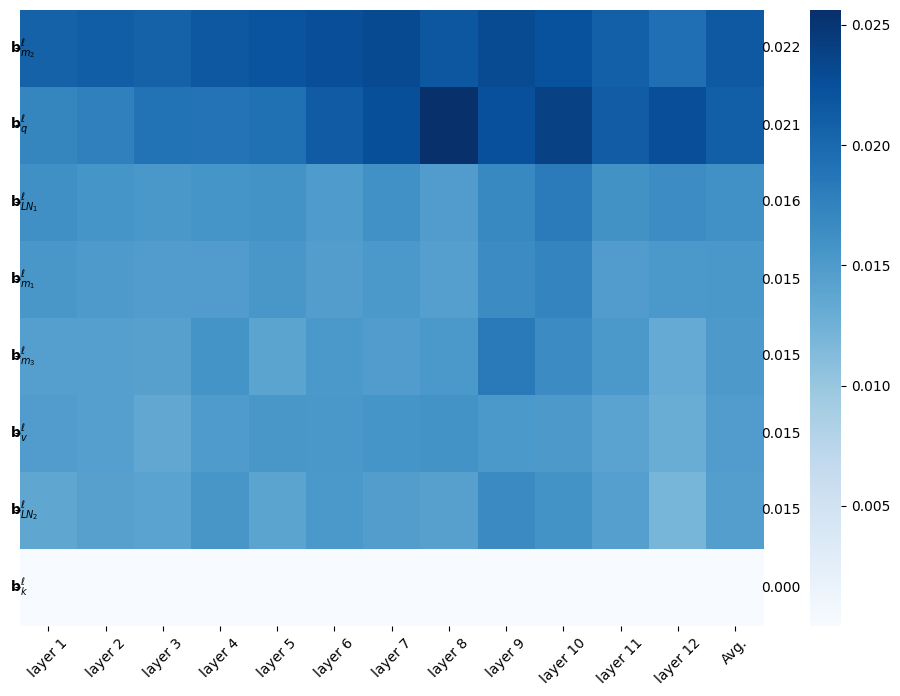

#########################################Our Bias-Efficient Approach#########################################


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


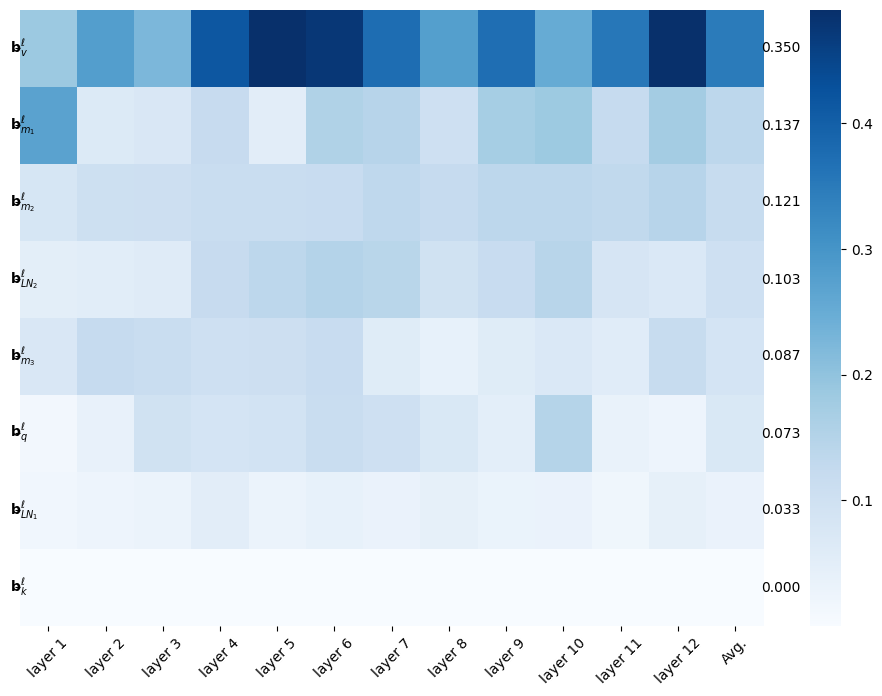

In [6]:
args = SimpleNamespace(
    output_path='./results',
    task_name='sst2',
    model_name='bert-base-cased',
    bias_terms_loop=False,
    fisher=False,
    fine_tune_type='bitfit',
    bias_terms=['all'],
    gpu_device=None,
    seed=0,
    learning_rate=None,
    epochs=16,
    batch_size=16,
    optimizer='adamw',
    save_evaluator=False,
    predict_test=False,
    verbose=True
)
main(args)

**_Fisher_ approach**

2025-07-23 12:57:13,024 - 625134634 - INFO - ############################################################################################
2025-07-23 12:57:13,025 - 625134634 - INFO - ############################################################################################
2025-07-23 12:57:13,026 - 625134634 - INFO - ############################################################################################
2025-07-23 12:57:13,026 - 625134634 - INFO - 
2025-07-23 12:57:13,027 - 625134634 - INFO - Training Details: 
2025-07-23 12:57:13,027 - 625134634 - INFO - ----------------------------------------------
2025-07-23 12:57:13,027 - 625134634 - INFO - Model Name: bert-base-cased
2025-07-23 12:57:13,028 - 625134634 - INFO - Task Name: sst2
2025-07-23 12:57:13,028 - 625134634 - INFO - Fine Tuning Type: bitfit
2025-07-23 12:57:13,028 - 625134634 - INFO - Output Directory: ./results
2025-07-23 12:57:13,029 - 625134634 - INFO - Running on CPU
2025-07-23 12:57:13,029 - 625134634 - INFO - Bi

Map: 100%|██████████| 1821/1821 [00:00<00:00, 19351.95 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




Trainable Components:
----------------------------------------

bert.embeddings.LayerNorm.bias   --->   torch.Size([768])
bert.encoder.layer.0.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.0.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.0.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.0.attention.output.dense.bias   --->   torch.Size([768])
bert.encoder.layer.0.attention.output.LayerNorm.bias   --->   torch.Size([768])
bert.encoder.layer.0.intermediate.dense.bias   --->   torch.Size([3072])
bert.encoder.layer.0.output.dense.bias   --->   torch.Size([768])
bert.encoder.layer.0.output.LayerNorm.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.output.dense.bias   --->   torch.Size([7

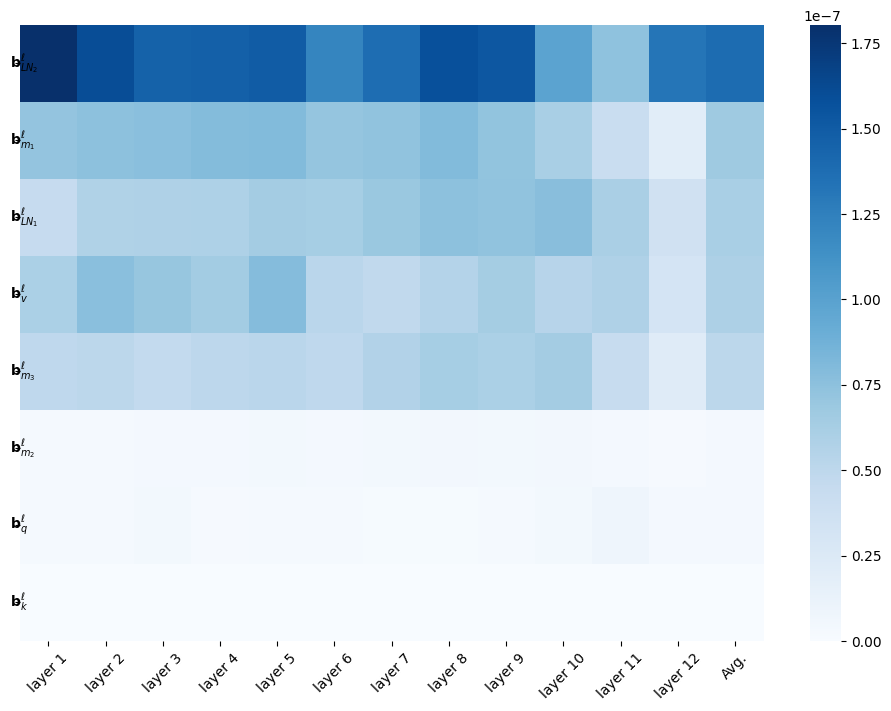

SystemExit: 

In [5]:
args = SimpleNamespace(
    output_path='./results',
    task_name='sst2',
    model_name='bert-base-cased',
    bias_terms_loop=False,
    fisher=True,
    fine_tune_type='bitfit',
    bias_terms=['all'],
    gpu_device=None,
    seed=0,
    learning_rate=None,
    epochs=1,
    batch_size=8,
    optimizer='adamw',
    save_evaluator=False,
    predict_test=False,
    verbose=True
)
main(args)

To get the performance of fine-tuning **b**<sub>v</sub> 

In [6]:
args = SimpleNamespace(
    output_path='./results',
    task_name='sst2',
    model_name='bert-base-cased',
    bias_terms_loop=True,
    fisher=False,
    fine_tune_type='bitfit',
    bias_terms=['value'],
    gpu_device=None,
    seed=0,
    learning_rate=None,
    epochs=16,
    batch_size=16,
    optimizer='adamw',
    save_evaluator=False,
    predict_test=False,
    verbose=True
)

main(args)


2025-07-23 13:04:09,264 - 625134634 - INFO - ############################################################################################
2025-07-23 13:04:09,265 - 625134634 - INFO - ############################################################################################
2025-07-23 13:04:09,266 - 625134634 - INFO - ############################################################################################
2025-07-23 13:04:09,267 - 625134634 - INFO - 
2025-07-23 13:04:09,267 - 625134634 - INFO - Training Details: 
2025-07-23 13:04:09,268 - 625134634 - INFO - ----------------------------------------------
2025-07-23 13:04:09,268 - 625134634 - INFO - Model Name: bert-base-cased
2025-07-23 13:04:09,268 - 625134634 - INFO - Task Name: sst2
2025-07-23 13:04:09,269 - 625134634 - INFO - Fine Tuning Type: bitfit
2025-07-23 13:04:09,269 - 625134634 - INFO - Output Directory: ./results
2025-07-23 13:04:09,269 - 625134634 - INFO - Running on CPU
2025-07-23 13:04:09,270 - 625134634 - INFO - Bi

Map: 100%|██████████| 1821/1821 [00:00<00:00, 13435.95 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




Trainable Components:
----------------------------------------

bert.encoder.layer.0.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.2.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.3.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.4.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.5.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.6.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.7.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.8.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.9.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.10.attention.self.value.bias   --->   torch.Size([768])
bert.encoder.layer.11.attention.self.value.bias   --->   torch.Size([768])
bert.pooler.dense.bias   --->   torch.Size([

To get the performance of fine-tuning **b**<sub>q</sub>

In [7]:
args = SimpleNamespace(
    output_path='./results',
    task_name='sst2',
    model_name='bert-base-cased',
    bias_terms_loop=True,
    fisher=False,
    fine_tune_type='bitfit',
    bias_terms=['query'],
    gpu_device=None,
    seed=0,
    learning_rate=None,
    epochs=16,
    batch_size=16,
    optimizer='adamw',
    save_evaluator=False,
    predict_test=False,
    verbose=True
)

main(args)


2025-07-23 13:42:39,706 - 625134634 - INFO - ############################################################################################
2025-07-23 13:42:39,708 - 625134634 - INFO - ############################################################################################
2025-07-23 13:42:39,708 - 625134634 - INFO - ############################################################################################
2025-07-23 13:42:39,709 - 625134634 - INFO - 
2025-07-23 13:42:39,710 - 625134634 - INFO - Training Details: 
2025-07-23 13:42:39,710 - 625134634 - INFO - ----------------------------------------------
2025-07-23 13:42:39,711 - 625134634 - INFO - Model Name: bert-base-cased
2025-07-23 13:42:39,712 - 625134634 - INFO - Task Name: sst2
2025-07-23 13:42:39,712 - 625134634 - INFO - Fine Tuning Type: bitfit
2025-07-23 13:42:39,712 - 625134634 - INFO - Output Directory: ./results
2025-07-23 13:42:39,713 - 625134634 - INFO - Running on CPU
2025-07-23 13:42:39,713 - 625134634 - INFO - Bi

Map: 100%|██████████| 1821/1821 [00:00<00:00, 19877.96 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




Trainable Components:
----------------------------------------

bert.encoder.layer.0.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.2.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.3.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.4.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.5.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.6.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.7.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.8.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.9.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.10.attention.self.query.bias   --->   torch.Size([768])
bert.encoder.layer.11.attention.self.query.bias   --->   torch.Size([768])
bert.pooler.dense.bias   --->   torch.Size([

To get the performance of fine-tuning **b**<sub>k</sub>

In [8]:
args = SimpleNamespace(
    output_path='./results',
    task_name='sst2',
    model_name='bert-base-cased',
    bias_terms_loop=True,
    fisher=False,
    fine_tune_type='bitfit',
    bias_terms=['key'],
    gpu_device=None,
    seed=0,
    learning_rate=None,
    epochs=16,
    batch_size=16,
    optimizer='adamw',
    save_evaluator=False,
    predict_test=False,
    verbose=True
)

main(args)


2025-07-23 14:30:16,723 - 625134634 - INFO - ############################################################################################
2025-07-23 14:30:16,724 - 625134634 - INFO - ############################################################################################
2025-07-23 14:30:16,725 - 625134634 - INFO - ############################################################################################
2025-07-23 14:30:16,726 - 625134634 - INFO - 
2025-07-23 14:30:16,726 - 625134634 - INFO - Training Details: 
2025-07-23 14:30:16,727 - 625134634 - INFO - ----------------------------------------------
2025-07-23 14:30:16,727 - 625134634 - INFO - Model Name: bert-base-cased
2025-07-23 14:30:16,727 - 625134634 - INFO - Task Name: sst2
2025-07-23 14:30:16,728 - 625134634 - INFO - Fine Tuning Type: bitfit
2025-07-23 14:30:16,728 - 625134634 - INFO - Output Directory: ./results
2025-07-23 14:30:16,728 - 625134634 - INFO - Running on CPU
2025-07-23 14:30:16,729 - 625134634 - INFO - Bi

Map: 100%|██████████| 1821/1821 [00:00<00:00, 19521.20 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




Trainable Components:
----------------------------------------

bert.encoder.layer.0.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.1.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.2.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.3.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.4.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.5.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.6.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.7.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.8.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.9.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.10.attention.self.key.bias   --->   torch.Size([768])
bert.encoder.layer.11.attention.self.key.bias   --->   torch.Size([768])
bert.pooler.dense.bias   --->   torch.Size([768])
classifier.weight 